# 05 — Distribuição dos clusters de risco (diagnóstico)

Os 6 clusters de `04_clusterizacao_risco` foram construídos **só** com as 6 features de resistência
adquirida. Aqui cruzamos esses clusters com atributos que **não** entraram no clustering, para
entender o que cada cluster é e onde ele aparece:

1. Espécie
2. Fonte de isolamento (`source_type`)
3. Região, estado e ano de coleta
4. Virulência (VFDB / abricate)
5. Features antigas (v1), agora só como diagnóstico

Para cada atributo categórico há dois heatmaps:
- **% por cluster**: composição de cada cluster (as colunas somam 100%).
- **Resíduo padronizado de Pearson** `(obs − esp) / √esp`: onde há **excesso** (vermelho) ou
  **falta** (azul) em relação ao esperado se cluster e atributo fossem independentes. |resíduo| > 2
  é aproximadamente significativo a 5% por célula. Esse heatmap corrige o efeito de tamanho: *K.
  pneumoniae* domina quase todos os clusters em % simplesmente porque é metade do recorte.

A força de cada associação vem resumida no **V de Cramér** (0 = independente, 1 = o atributo
determina o cluster).

Os rótulos usados são os de todos os genomas (treino = fit; validação/teste = projeção pelo modelo
do treino). Como a análise é descritiva, não há vazamento.

In [1]:
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, kruskal


def encontrar_raiz_repo(marcadores=(".git", "data")):
    for pasta in [Path.cwd(), *Path.cwd().parents]:
        if all((pasta / m).exists() for m in marcadores):
            return pasta
    raise FileNotFoundError(f"Nao achei {marcadores} subindo a partir de {Path.cwd()}")


RAIZ = encontrar_raiz_repo()
pd.set_option("display.width", 200)

In [2]:
clusters = pd.read_csv(RAIZ / "data/processed/clusters_risco.csv", index_col=0)
metadata = pd.read_csv(RAIZ / "data/raw/metadata_recorte.csv", index_col=0)
df = clusters.join(metadata.drop(columns=["Species"]), how="left")

# rótulo curto pro eixo dos heatmaps
ROTULO = {
    0: "C0 MBL+ESBL",
    1: "C1 ESBL",
    2: "C2 carb. serina",
    3: "C3 carb. serina+ESBL",
    4: "C4 carb.+metilase 16S",
    5: "C5 sem mecanismo",
}
# confere que o mapeamento curto bate com o perfil salvo pelo 07
print(df.groupby("cluster")["perfil"].first().to_string())
df["cl"] = pd.Categorical(df["cluster"].map(ROTULO), categories=list(ROTULO.values()), ordered=True)
print(f"\n{len(df)} genomas")
df["cl"].value_counts().sort_index()

cluster
0                          C0: MBL + ESBL (plasm. 80%)
1                           C1: ESBL sem carbapenemase
2                C2: carbapenemase serina (plasm. 61%)
3         C3: carbapenemase serina + ESBL (plasm. 96%)
4    C4: carbapenemase serina + metilase 16S (plasm...
5                C5: sem mecanismo principal adquirido

2226 genomas


cl
C0 MBL+ESBL              219
C1 ESBL                  315
C2 carb. serina          491
C3 carb. serina+ESBL     438
C4 carb.+metilase 16S    297
C5 sem mecanismo         466
Name: count, dtype: int64

## Funções de apoio

In [3]:
def cramers_v(ct):
    chi2, p, _, _ = chi2_contingency(ct)
    n = ct.values.sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1))), p


def residuos_pearson(ct):
    _, _, _, esperado = chi2_contingency(ct)
    return (ct - esperado) / np.sqrt(esperado)


def heatmaps_crosstab(serie, titulo, min_n=10, figsize=(15, 5)):
    """% por cluster + resíduo de Pearson; categorias com < min_n genomas viram 'outras'."""
    s = serie.where(serie.map(serie.value_counts()) >= min_n, "outras")
    ct = pd.crosstab(s, df["cl"])
    ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]
    v, p = cramers_v(ct)

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    sns.heatmap(ct / ct.sum(axis=0), annot=ct.values, fmt="d", cmap="Blues", ax=axes[0],
                cbar_kws={"label": "fração do cluster"})
    axes[0].set(title=f"{titulo} — % por cluster (número = contagem)", xlabel="", ylabel="")
    res = residuos_pearson(ct)
    lim = max(4, np.nanmax(np.abs(res.values)))
    sns.heatmap(res, annot=True, fmt=".1f", cmap="RdBu_r", center=0, vmin=-lim, vmax=lim, ax=axes[1],
                cbar_kws={"label": "resíduo padronizado"})
    axes[1].set(title=f"{titulo} — resíduo de Pearson  (V de Cramér = {v:.2f}, p = {p:.1e})", xlabel="", ylabel="")
    for ax in axes:
        ax.tick_params(axis="x", rotation=35)
        plt.setp(ax.get_xticklabels(), ha="right")
    plt.tight_layout()
    plt.show()
    return {"atributo": titulo, "cramers_v": v, "p_valor": p, "n": int(ct.values.sum())}


associacoes = []

## 1. Espécie

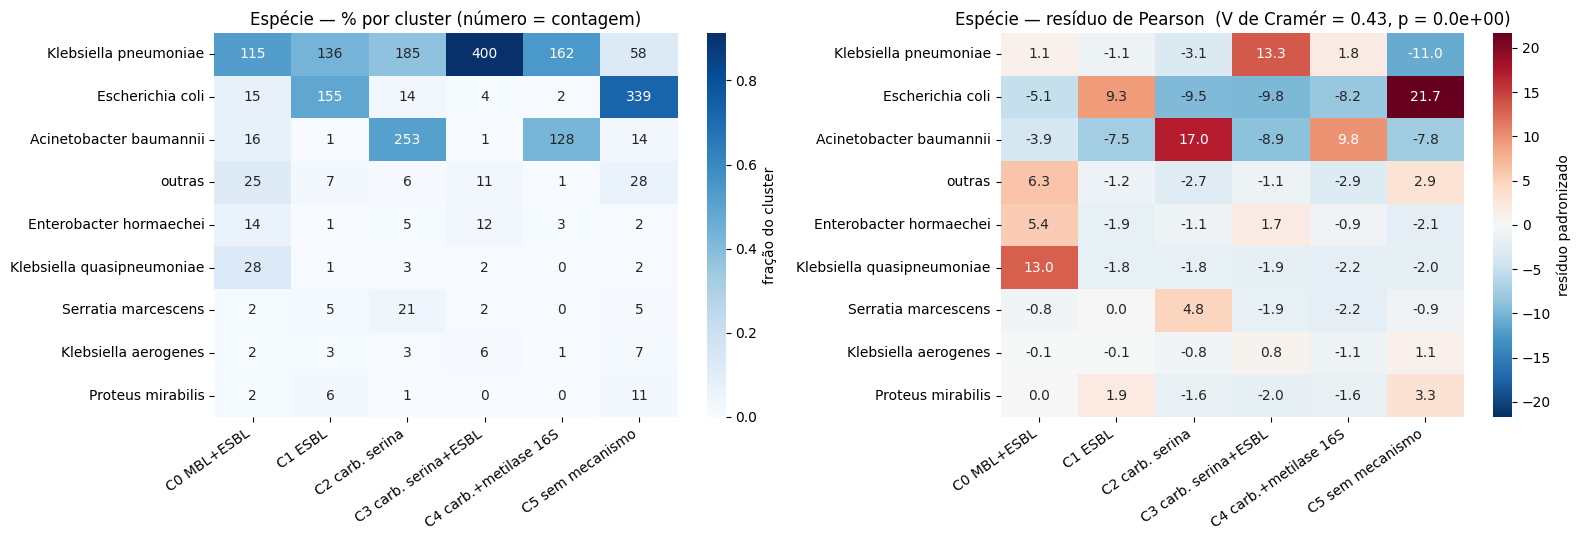

In [4]:
associacoes.append(heatmaps_crosstab(df["Species"], "Espécie", min_n=14, figsize=(16, 5.5)))

## 2. Fonte de isolamento

`source_type` (categorias padronizadas no `00_ajuste_metadados`). "Unknown" fica visível de
propósito: se um cluster concentrar Unknown, a leitura de fonte daquele cluster é mais frágil.

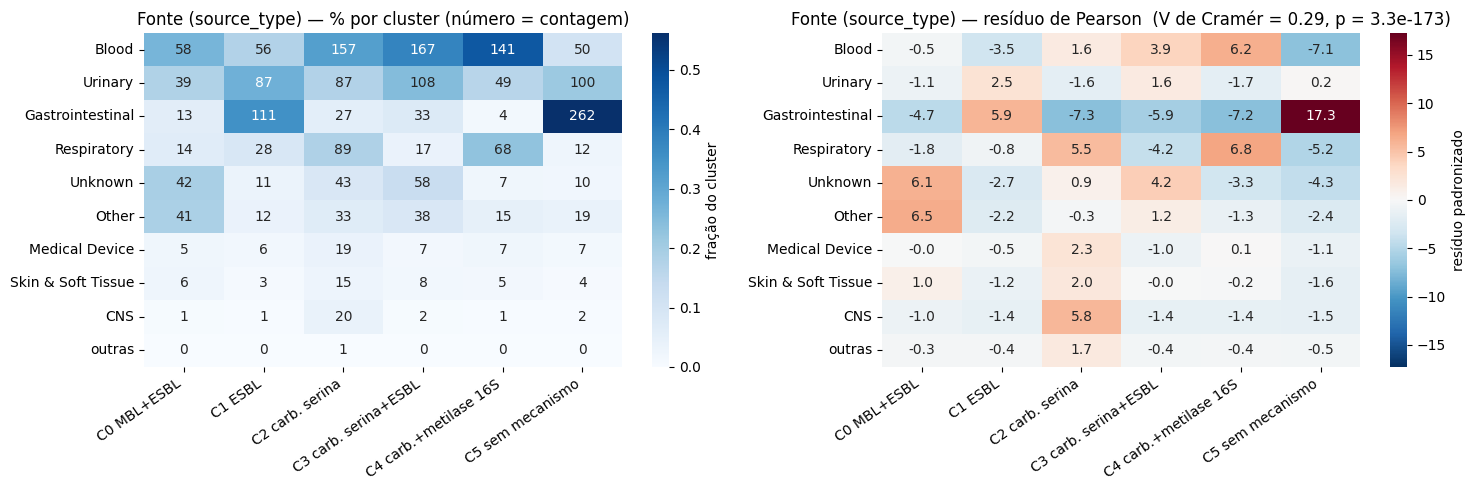

In [5]:
associacoes.append(heatmaps_crosstab(df["source_type"], "Fonte (source_type)"))

**Vigilância × infecção**: swab retal e de vigilância são colonização (triagem de portador), não
infecção. Separá-los mostra se algum perfil é mais "de colonização" que "de infecção invasiva".

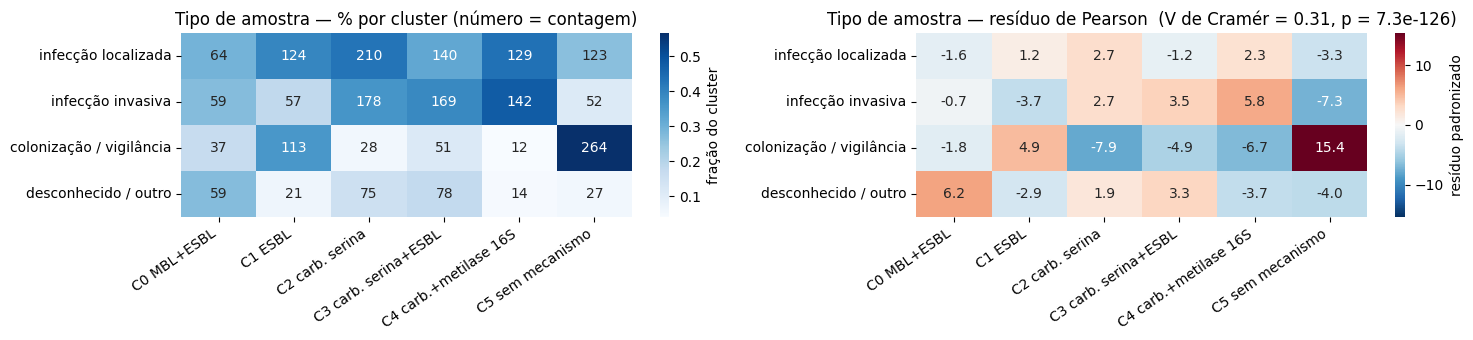

In [6]:
src = df["Source"].str.lower().fillna("")
df["tipo_amostra"] = np.select(
    [src.str.contains("rectal|surveillance|swab|stool|feces|fecal"),
     df["source_type"].isin(["Blood", "CNS", "Body Fluid"]),
     df["source_type"].isin(["Urinary", "Respiratory", "Skin & Soft Tissue", "Medical Device"])],
    ["colonização / vigilância", "infecção invasiva", "infecção localizada"],
    default="desconhecido / outro",
)
associacoes.append(heatmaps_crosstab(df["tipo_amostra"], "Tipo de amostra", figsize=(15, 3.5)))

## 3. Geografia e tempo

**Problema no metadado**: a coluna `Região` tem SP (870 genomas) marcado como "Sul" e 7 genomas do AM
como "Noroeste", que não é uma região do Brasil. Aqui a região é **recalculada a partir do `Estado`**.
O `metadata_recorte.csv` não foi alterado; o erro provavelmente vem do `00_ajuste_metadados`.

In [7]:
print(pd.crosstab(df["Estado"], df["Região"]).loc[["SP", "AM"]])

REGIAO_UF = {
    "Norte": ["AC", "AP", "AM", "PA", "RO", "RR", "TO"],
    "Nordeste": ["AL", "BA", "CE", "MA", "PB", "PE", "PI", "RN", "SE"],
    "Centro-Oeste": ["DF", "GO", "MT", "MS"],
    "Sudeste": ["ES", "MG", "RJ", "SP"],
    "Sul": ["PR", "RS", "SC"],
}
UF_PARA_REGIAO = {uf: reg for reg, ufs in REGIAO_UF.items() for uf in ufs}
df["regiao_corrigida"] = df["Estado"].map(UF_PARA_REGIAO).fillna("sem informação")
df["regiao_corrigida"].value_counts()

Região  Centro-oeste  Nordeste  Noroeste  Norte  Sudeste  Sul
Estado                                                       
SP                 0         0         0      0        0  868
AM                 0         0         7     23        0    0


regiao_corrigida
Sudeste           1039
sem informação     893
Sul                136
Nordeste            85
Norte               62
Centro-Oeste        11
Name: count, dtype: int64

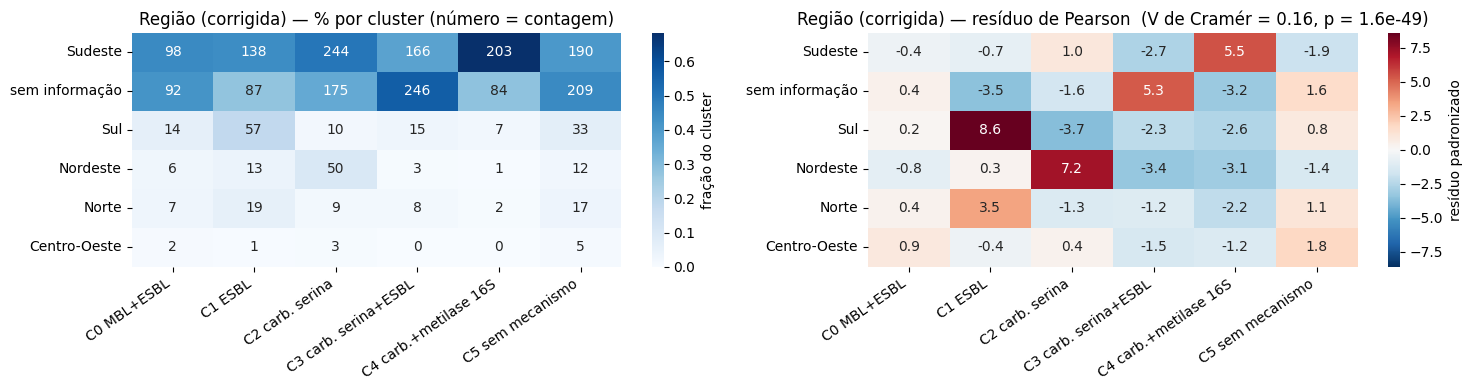

In [8]:
associacoes.append(heatmaps_crosstab(df["regiao_corrigida"], "Região (corrigida)", figsize=(15, 4)))

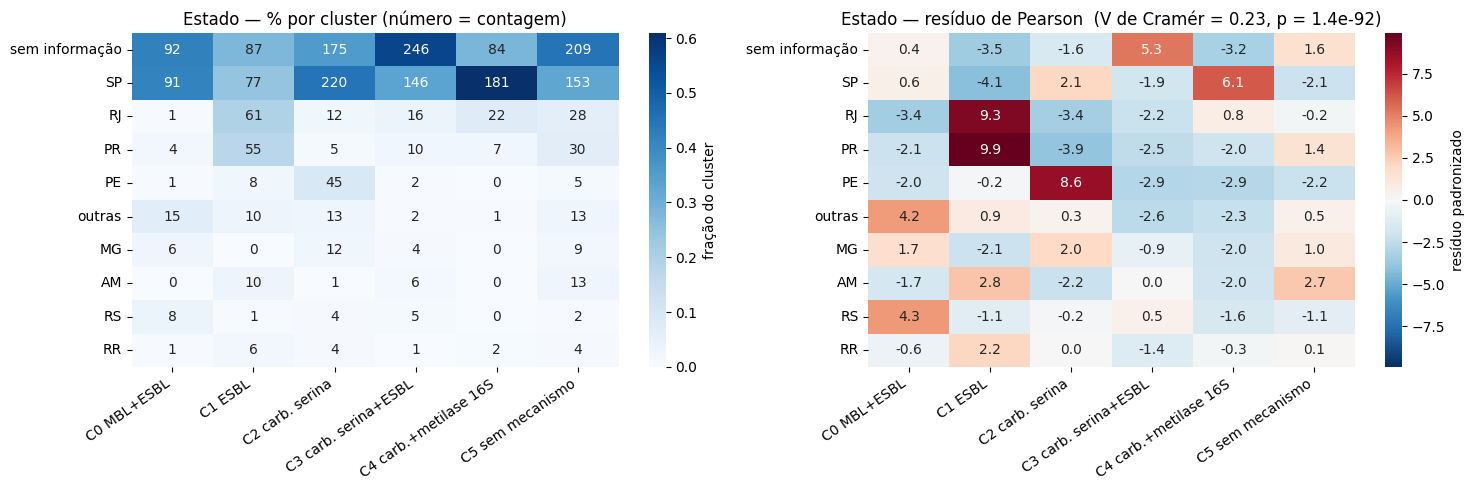

In [9]:
associacoes.append(heatmaps_crosstab(df["Estado"].fillna("sem informação"), "Estado", min_n=15))

### Ano de coleta

Em faixas, para não pulverizar a tabela (a maioria dos genomas é de 2011 em diante).

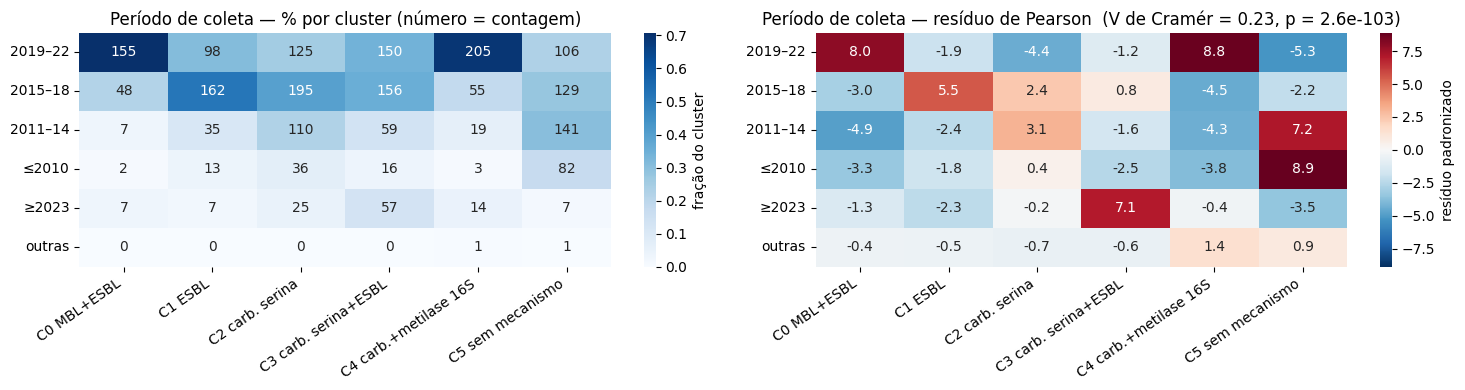

In [10]:
ano = df["Date"]
df["periodo"] = pd.cut(ano, bins=[0, 2010, 2014, 2018, 2022, 3000],
                       labels=["≤2010", "2011–14", "2015–18", "2019–22", "≥2023"]).astype(str)
associacoes.append(heatmaps_crosstab(df["periodo"].replace("nan", "sem informação"), "Período de coleta", figsize=(15, 4)))

Proporção de cada cluster ao longo do tempo, por ano (anos com ≥ 30 genomas):

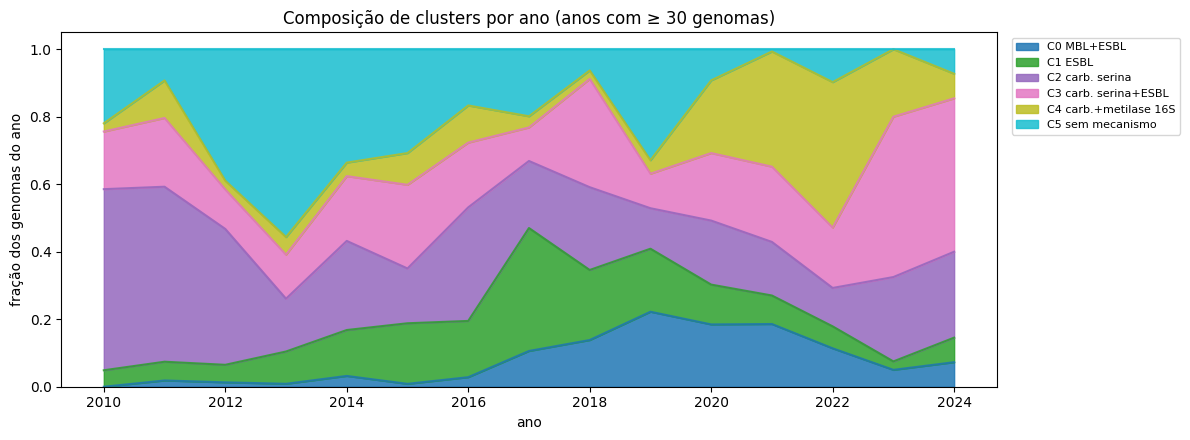

In [11]:
anos_ok = ano.value_counts().loc[lambda s: s >= 30].index
prop_ano = pd.crosstab(ano[ano.isin(anos_ok)].astype(int), df.loc[ano.isin(anos_ok), "cl"], normalize="index")
ax = prop_ano.plot(kind="area", stacked=True, figsize=(12, 4.5), cmap="tab10", alpha=0.85)
ax.set(ylabel="fração dos genomas do ano", xlabel="ano", title="Composição de clusters por ano (anos com ≥ 30 genomas)")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

**Cuidado com confundimento**: espécie, estado e ano não são independentes entre si (ex: um estudo
grande de *A. baumannii* em um estado num ano). Uma associação cluster × estado pode ser, na verdade,
cluster × espécie. Para separar, a seção 3.1 olha estado **dentro de *K. pneumoniae***, a espécie
presente em todos os clusters.

### 3.1 Estado e período só em *K. pneumoniae*

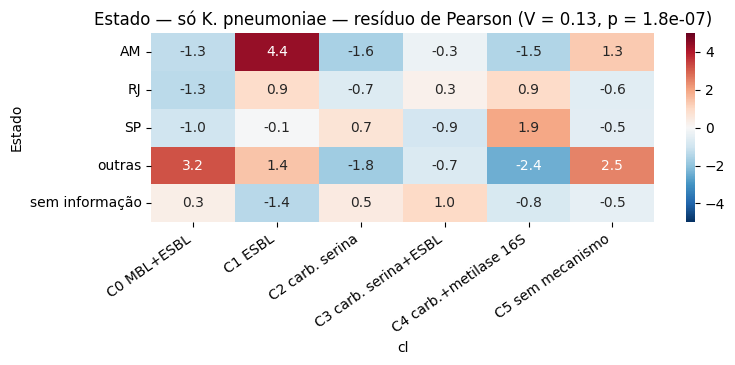

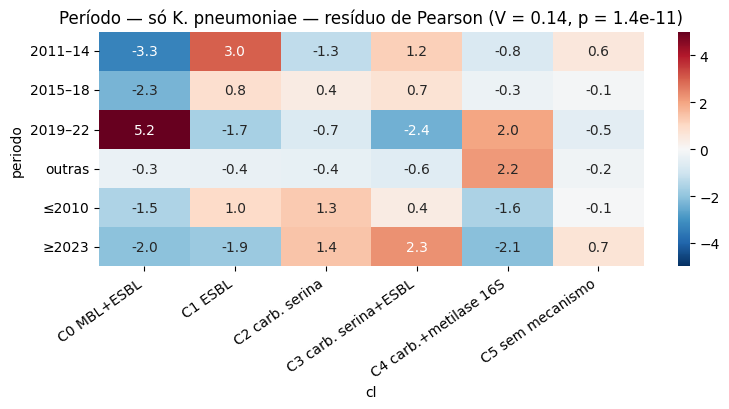

In [12]:
kp = df["Species"] == "Klebsiella pneumoniae"
df_kp = df[kp]
for col, titulo in [("Estado", "Estado — só K. pneumoniae"), ("periodo", "Período — só K. pneumoniae")]:
    s = df_kp[col].fillna("sem informação").replace("nan", "sem informação")
    s = s.where(s.map(s.value_counts()) >= 15, "outras")
    ct = pd.crosstab(s, df_kp["cl"])
    v, p = cramers_v(ct)
    plt.figure(figsize=(8, 0.45 * len(ct) + 1.5))
    sns.heatmap(residuos_pearson(ct), annot=True, fmt=".1f", cmap="RdBu_r", center=0, vmin=-5, vmax=5)
    plt.title(f"{titulo} — resíduo de Pearson (V = {v:.2f}, p = {p:.1e})")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()
    associacoes.append({"atributo": titulo, "cramers_v": v, "p_valor": p, "n": int(ct.values.sum())})

## 4. Virulência (VFDB via abricate)

Mesma lógica do `08_v1_old_make_features`: categoria VFDB extraída do campo `PRODUCT` (âncora em
`(VFCxxxx)`) e escore = nº de **categorias** de virulência presentes no genoma.

Diferença: aqui o escore usa todos os contigs, não só os cromossômicos, porque o mapa
contig → tipo (`dataset.contigs`) depende do ambiente ARGOS. Se o `vfdb_all_hits.csv` não
estiver em `data/raw/`, a seção é pulada.

In [13]:
CAMINHO_VFDB = RAIZ / "data/raw/vfdb_all_hits.csv"
TEM_VFDB = CAMINHO_VFDB.exists()
print("VFDB encontrado" if TEM_VFDB else f"AVISO: {CAMINHO_VFDB} não existe — seção de virulência pulada")


def extrair_categoria_vfdb(product):
    m = re.search(r"-\s*([^()]+?)\s*\(VFC\d+\)", str(product))
    return m.group(1).strip() if m else None


if TEM_VFDB:
    vfdb = pd.read_csv(CAMINHO_VFDB)
    vfdb["sample_id"] = vfdb["sample"].str.extract(r"(GC[AF]_\d+\.\d+)")[0]
    vfdb["categoria"] = vfdb["PRODUCT"].apply(extrair_categoria_vfdb)
    vfdb = vfdb[vfdb["sample_id"].isin(df.index)]
    print(f"{len(vfdb)} hits em {vfdb['sample_id'].nunique()} genomas do recorte | "
          f"sem categoria: {vfdb['categoria'].isna().sum()}")

    # presença de categoria (0/1) e nº de genes VF distintos, por genoma
    cat_bin = pd.crosstab(vfdb["sample_id"], vfdb["categoria"]).clip(upper=1).reindex(df.index, fill_value=0)
    df["virulence_score"] = cat_bin.sum(axis=1)
    df["n_genes_vf"] = vfdb.groupby("sample_id")["GENE"].nunique().reindex(df.index, fill_value=0)

AVISO: /home/lusa/Teste_Argos/ml_isolados_brasileiros/data/raw/vfdb_all_hits.csv não existe — seção de virulência pulada


### 4.1 Escore de virulência por cluster

Mostrado também separado por espécie: o repertório VFDB é muito dependente de espécie (ex:
sideróforos e cápsula de *Klebsiella* × *Acinetobacter*). Comparar clusters sem controlar espécie
mediria espécie de novo.

In [14]:
if TEM_VFDB:
    esp3 = df["Species"].where(df["Species"].isin(
        ["Klebsiella pneumoniae", "Escherichia coli", "Acinetobacter baumannii"]), "outras")
    fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
    sns.boxplot(data=df, x="cl", y="n_genes_vf", ax=axes[0], color="lightgrey")
    axes[0].set(title="nº de genes de virulência distintos", xlabel="")
    sns.boxplot(data=df.assign(esp=esp3), x="cl", y="n_genes_vf", hue="esp", ax=axes[1])
    axes[1].set(title="... por espécie", xlabel="")
    for ax in axes:
        ax.tick_params(axis="x", rotation=30)
    axes[1].legend(fontsize=7)
    plt.tight_layout()
    plt.show()

    linhas = []
    for esp, sub in [("todas", df), *df.assign(esp=esp3).groupby("esp")]:
        grupos = [g["n_genes_vf"].values for _, g in sub.groupby("cl", observed=True) if len(g) >= 5]
        if len(grupos) > 1:
            h, p = kruskal(*grupos)
            linhas.append({"espécie": esp, "H_kruskal": h, "p_valor": p,
                           **sub.groupby("cl", observed=True)["n_genes_vf"].median().rename(lambda c: f"mediana {c}")})
    display(pd.DataFrame(linhas).round(3))

### 4.2 Categorias VFDB por cluster

Fração de genomas do cluster que tem cada categoria. Para evitar o efeito espécie, o heatmap é
feito só em *K. pneumoniae*, que aparece nos 6 clusters.

In [15]:
if TEM_VFDB:
    for titulo, mask in [("todas as espécies", df.index == df.index), ("só K. pneumoniae", kp.values)]:
        frac = cat_bin[mask].groupby(df.loc[mask, "cl"], observed=True).mean().T
        frac = frac.loc[frac.max(axis=1).sort_values(ascending=False).index]
        plt.figure(figsize=(10, 0.35 * len(frac) + 1.5))
        sns.heatmap(frac, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1)
        plt.title(f"Fração de genomas com cada categoria VFDB — {titulo}")
        plt.xticks(rotation=35, ha="right")
        plt.tight_layout()
        plt.show()

## 5. Features antigas (v1) como diagnóstico

As features v1 misturavam resistoma intrínseco e adquirido, e por isso **codificavam espécie**. Como
diagnóstico elas ainda são úteis: mostram como cada cluster novo se posiciona no "espaço antigo".
Esperado:
- `pct_BD_carbapenemase` alto no C2/C4 (OXA-51 + OXA-23 do *A. baumannii*);
- `pct_nao_hidrolise` alto no C5 (sem gene adquirido, o denominador é só o intrínseco).

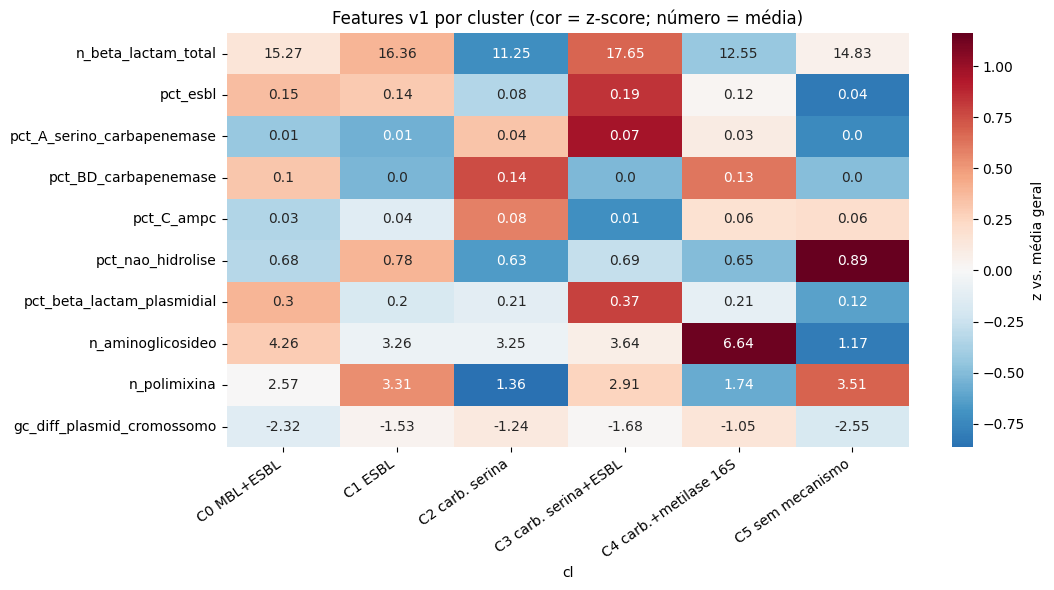

In [16]:
v1 = pd.read_csv(RAIZ / "data/raw/features_v1.csv", index_col=0)
V1 = [c for c in v1.columns]
dv1 = df[["cl"]].join(v1, how="left")

media = dv1.groupby("cl", observed=True)[V1].mean()
z = (media - dv1[V1].mean()) / dv1[V1].std()
plt.figure(figsize=(11, 6))
sns.heatmap(z.T, cmap="RdBu_r", center=0, annot=media.T.round(2), fmt="",
            cbar_kws={"label": "z vs. média geral"})
plt.title("Features v1 por cluster (cor = z-score; número = média)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

Força de associação de cada feature v1 com o cluster: Kruskal-Wallis (as colunas são assimétricas
e têm muitos zeros) e η² (fração da variância explicada pelo cluster). Para comparar, a última
coluna mostra o η² da mesma feature com a **espécie**. Onde η²(espécie) > η²(cluster), a feature v1
está mais ligada à taxonomia do que ao perfil de risco novo.

In [17]:
def eta2(x, grupos):
    x, grupos = x[x.notna()], grupos[x.notna()]
    media = x.mean()
    entre = sum(len(g) * (g.mean() - media) ** 2 for _, g in x.groupby(grupos, observed=True))
    return entre / ((x - media) ** 2).sum()


esp_agr = df["Species"].where(df["Species"].map(df["Species"].value_counts()) >= 14, "outras")
linhas = []
for c in V1:
    grupos = [g.dropna().values for _, g in dv1.groupby("cl", observed=True)[c]]
    h, p = kruskal(*grupos)
    linhas.append({"feature_v1": c, "H_kruskal": h, "p_valor": p,
                   "eta2_cluster": eta2(dv1[c], dv1["cl"]), "eta2_especie": eta2(dv1[c], esp_agr)})
pd.DataFrame(linhas).sort_values("eta2_cluster", ascending=False).round(3)

,feature_v1,H_kruskal,p_valor,eta2_cluster,eta2_especie
5,pct_nao_hidrolise,1093.623,0.0,0.461,0.617
2,pct_A_serino_carbapenemase,1002.836,0.0,0.381,0.442
8,n_polimixina,849.396,0.0,0.363,0.942
3,pct_BD_carbapenemase,999.313,0.0,0.332,0.917
1,pct_esbl,803.302,0.0,0.329,0.420
7,n_aminoglicosideo,921.809,0.0,0.322,0.135
0,n_beta_lactam_total,557.450,0.0,0.252,0.760
6,pct_beta_lactam_plasmidial,522.200,0.0,0.230,0.498
4,pct_C_ampc,471.632,0.0,0.202,0.870
9,gc_diff_plasmid_cromossomo,190.788,0.0,0.016,0.058


## 6. Resumo das associações

V de Cramér de cada atributo categórico com o cluster. Referência grosseira (Cohen, gl ≥ 5):
~0,1 fraca, ~0,3 moderada, ≥ 0,5 forte.

In [18]:
resumo = pd.DataFrame(associacoes).sort_values("cramers_v", ascending=False).reset_index(drop=True)
resumo.round(4)

,atributo,cramers_v,p_valor,n
0,Espécie,0.4345,0.0,2226
1,Tipo de amostra,0.3086,0.0,2226
2,Fonte (source_type),0.2947,0.0,2226
3,Estado,0.2268,0.0,2226
4,Período de coleta,0.2253,0.0,2226
5,Região (corrigida),0.1650,0.0,2226
6,Período — só K. pneumoniae,0.1403,0.0,1056
7,Estado — só K. pneumoniae,0.1287,0.0,1056


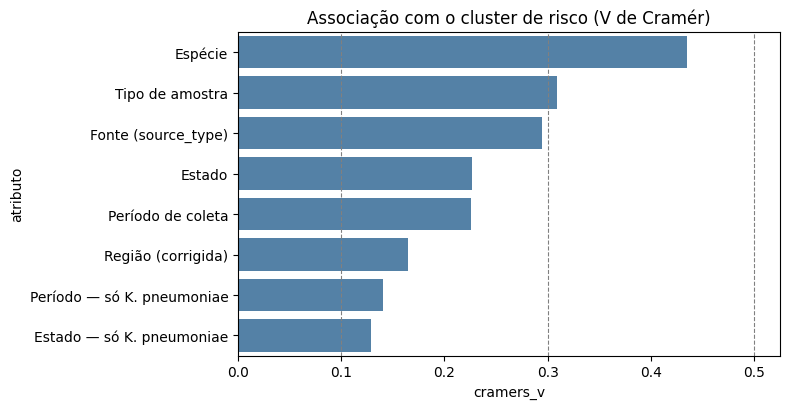

In [19]:
plt.figure(figsize=(8, 0.4 * len(resumo) + 1))
sns.barplot(data=resumo, y="atributo", x="cramers_v", color="steelblue")
for x in (0.1, 0.3, 0.5):
    plt.axvline(x, ls="--", c="grey", lw=0.8)
plt.title("Associação com o cluster de risco (V de Cramér)")
plt.tight_layout()
plt.show()